In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import warnings 

warnings.filterwarnings("ignore")

In [ ]:
import os
import pandas as pd
import numpy as np
from rdkit import Chem
from DFTStructureGenerator.logfile_process import Logfile

In [ ]:
duplicate_N_id = [9, 43, 285, 310, 314, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 372, 375, 376]

In [25]:
benchmark_b = [388, 391, 394, 401, 427] 
benchmark_l = [1, 33, 46, 69, 72, 146]
benchmark_cl = [443, 447, 475, 477, 490, 519, 506]
reaction_df = pd.read_csv(r'Data\TS\Borane_all.csv')
Cl_df = pd.read_csv(r'Data\csvs\reactants_Cl.csv')
Borane_Ligand_df = pd.read_csv(r'Data\csvs\reactants_B_N.csv')
temp_reaction_df = reaction_df.loc[np.isin(reaction_df['B_Index'], benchmark_b) & np.isin(reaction_df['N_Index'], benchmark_l)& np.isin(reaction_df['Cl_Index'], benchmark_cl)]
calc_dict = {}
for row_id, row in temp_reaction_df.iterrows():
    B_idx, N_idx, Cl_idx = row['B_Index'], row['N_Index'], row['Cl_Index']
    BN_name = f"B_{B_idx:05}_Nu_{N_idx:05}_r"
    Cl_name = f'Cl_{Cl_idx:05}_r'
    ts_name = f'B_{B_idx:05}_Nu_{N_idx:05}_Cl_{Cl_idx:05}'
    for name, multi in zip([BN_name, Cl_name, ts_name], [2,1,2]):
        if name not in calc_dict:
            smiles, atoms, _ = combined_data[name]
            calc_dict[name] = [atoms.symbols, atoms.positions, multi]

NameError: name 'combined_data' is not defined

In [26]:
import pickle
calc_dict = pickle.load(open(r'E:\work\B_Cl_Nu\Benchmark_new\calc_dict.pkl', 'rb'))

In [5]:
dft_methods = {
    "B3PW91-D3": "B3PW91/6-311+G(d,p) em=gd3BJ SCRF=(smd,solvent=Toluene)", 
    "CAM-B3LYP-D3": "CAM-B3LYP/6-311+G(d,p) em=gd3bj SCRF=(smd,solvent=Toluene)", 
    "M06-D3": "M06/6-311+G(d,p) em=gd3 SCRF=(smd,solvent=Toluene)", 
    "M06L-D3": "M06L/6-311+G(d,p) em=gd3 SCRF=(smd,solvent=Toluene)",
    "M062X": "6-311+g(d,p) scrf=(smd,solvent=toluene) m062x",
    "M062X-def2TZVP": "M062X/def2TZVP SCRF=(smd,solvent=Toluene)",
    "MN15L": "MN15L/6-311+G(d,p) SCRF=(smd,solvent=Toluene)", 
    "MN15": "MN15/6-311+G(d,p) SCRF=(smd,solvent=Toluene)",
    "PBE0-D3": "PBE1PBE/6-311+G(d,p) em=GD3BJ SCRF=(smd,solvent=Toluene)", 
    "PBE-D3": "PBEPBE/6-311+G(d,p) em=GD3BJ SCRF=(smd,solvent=Toluene)", 
    "PW6B95D3": "PW6B95D3/6-311+G(d,p) SCRF=(smd,solvent=Toluene)", 
    "TPSS-D3": "TPSSTPSS/6-311+G(d,p) em=gd3bj SCRF=(smd,solvent=Toluene)",
    "TPSSh": "TPSSh/6-311+G(d,p) SCRF=(smd,solvent=Toluene)", 
    "wB97XD": "wB97XD/6-311+G(d,p) SCRF=(smd,solvent=Toluene)",
    "M052X": "M052X/6-31G*", 
    "M052X-SMD": "M052X/6-31G* SCRF=(smd,solvent=Toluene)",
}

In [ ]:
from DFTStructureGenerator.FormatConverter import block_to_gjf
dft_path = r'E:\work\B_Cl_Nu\Benchmark_new\SPE'
for key in dft_methods.keys():
    method = dft_methods[key]
    for name in calc_dict.keys():
        atom, position, multi = calc_dict[name]
        block_to_gjf(atom, position, f"{dft_path}/{key}_{name}.gjf", method=method, multiplicity=multi, charge=0)
        

In [47]:
import glob
for name in calc_dict.keys():
    atoms, position, multi = calc_dict[name]
    with open(rf"E:\work\B_Cl_Nu\Benchmark_new\wb97M-V\wB97M-V_{name}.inp", "wt") as f:
        f.write('! wB97M-V def2-TZVPP RIJCOSX def2/J def2-TZVPP/C tightSCF noautostart defgrid3' + '\n')
        f.write('%maxcore 2000\n%pal nprocs 32 end\n%scf\nMaxIter 500\nend\n\n%cpcm\nSMD true\nSMDsolvent "Toluene"\nend\n\n')
        f.write(f'* xyz 0 {multi}\n')
        for atom, pos in zip(atoms, position):
            f.write(f'{atom} {pos[0]} {pos[1]} {pos[2]}\n')
        f.write('*\n')

In [ ]:
for name in calc_dict.keys():
    atoms, position, multi = calc_dict[name]
    with open(rf"E:\work\B_Cl_Nu\Benchmark_new\DLPNO2\DLPNO_{name}.inp", "wt") as f:
        f.write('! DLPNO-CCSD(T) normalPNO RIJCOSX cc-pVTZ cc-pVTZ/C def2/J TightSCF noautostart miniprint nopop' + '\n')
        f.write('%maxcore 2000\n%pal nprocs 32 end\n\n')
        f.write(f'* xyz 0 {multi}\n')
        for atom, pos in zip(atoms, position):
            f.write(f'{atom} {pos[0]} {pos[1]} {pos[2]}\n')
        f.write('*\n')

In [ ]:
import shutil
for name in calc_dict.keys():
    if name.startswith('B'):
        if "Cl" not in name:
            B_idx, N_idx = int(name.split("_")[1]), int(name.split("_")[3])
            target_df = Borane_Ligand_df.loc[Borane_Ligand_df['B_Index'] == B_idx]
            target_df = target_df.loc[target_df['N_Index'] == N_idx]
            conf_id = target_df.iloc[0]['conf_idxs_r']
            N_atom = target_df.iloc[0]['N_Atomid']
            log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\B_N_r\B_{B_idx:05}_Nu_{N_idx:05}_r_{conf_id:04}.log'
            if N_idx in duplicate_N_id:
                log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\B_N_r_d\B_{B_idx:05}_Nu_{N_idx:05}_Naid_{N_atom:05}_r_{conf_id:04}.log'
            shutil.copy(log_file, rf'E:\work\B_Cl_Nu\Benchmark_new\OPT\{name}.log')
        else:
            B_idx, N_idx, Cl_idx = int(name.split("_")[1]), int(name.split("_")[3]), int(name.split("_")[5])
            target_df = reaction_df.loc[(reaction_df['B_Index'] == B_idx) & (reaction_df['N_Index'] == N_idx) & (reaction_df['Cl_Index'] == Cl_idx)]
            conf_id = target_df.iloc[0]['conf_idxs_ts']
            log_file = rf'E:\work\B_Cl_Nu\Sum\TS_needIRC\B_{B_idx:05}_Nu_{N_idx:05}_Cl_{Cl_idx:05}.log'
            if not os.path.exists(log_file):
                log_file = rf'E:\work\B_Cl_Nu\Sum\TS_needIRC\B_{B_idx:05}_Nu_{N_idx:05}_Cl_{Cl_idx:05}_{conf_id:04}.log'
            shutil.copy(log_file, rf'E:\work\B_Cl_Nu\Benchmark_new\OPT\{name}.log')
    if name.startswith("Cl"):
        Cl_idx = int(name.split("_")[1])
        target_df = Cl_df.loc[Cl_df['Index'] == Cl_idx]
        conf_id = target_df.iloc[0]['conf_idxs_r']
        log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\Cl_r\Cl_{Cl_idx:05}_r_{conf_id:04}.log'
        shutil.copy(log_file, rf'E:\work\B_Cl_Nu\Benchmark_new\OPT\{name}.log')
    

In [34]:
import glob, shutil
output_file = glob.glob("E:\work\B_Cl_Nu\Benchmark_new\*\*.inp") +  glob.glob("E:\work\B_Cl_Nu\Benchmark_new\*\*.gjf")
for file in output_file:
    dir, base = os.path.split(file)
    base_ = base.replace("Nu", "L")
    shutil.move(file, os.path.join(dir, base_))

In [36]:
all_energies = {}
G_cor = {}
for name in calc_dict.keys():
    log = Logfile(rf'E:\work\B_Cl_Nu\Benchmark_new\OPT\{name}.log')
    G_cor[name] = log.all_engs[-1]
    for method in dft_methods.keys():
        log_file = rf'E:\work\B_Cl_Nu\Benchmark_new\SPE\{method}_{name}.log'
        if "M05" in method:
            log_file = rf'E:\work\B_Cl_Nu\Benchmark_new\M052X_SMD_cor\{method}_{name}.log'
        temp_log = Logfile(log_file)
        all_energies[f"{name}_{method}"] = G_cor[name] + temp_log.all_engs[-1]
    for method in ['wB97M-V', "DLPNO"]:
        method_ = method
        # if method == "DLPNO":
        #     method_ = "DLPNO_new"
        if not os.path.exists(rf'E:\work\B_Cl_Nu\Benchmark_new\{method_}\{method}_{name}.out'):
            all_energies[f"{name}_{method}"] = -1
            continue
        with open(rf'E:\work\B_Cl_Nu\Benchmark_new\{method_}\{method}_{name}.out', "rt") as f:
            eng = 0
            for line in f.readlines():
                if "FINAL SINGLE POINT ENERGY" in line:
                    eng = float(line.split()[-1])
                    break
        all_energies[f"{name}_{method}"] = G_cor[name] + eng

In [38]:
reaction_df = pd.read_csv(r'Data\TS\Borane_all.csv')
all_column = ['B3PW91-D3', 'CAM-B3LYP-D3', 'M06-D3', 'M06L-D3', 'M062X', 'M062X-def2TZVP', 'MN15L', 'MN15', 'PBE0-D3', 'PBE-D3', 'PW6B95D3', 'TPSS-D3', 'TPSSh', 'wB97XD'] + ['wB97M-V', "DLPNO"] + ['Test']
all_results = {method:[] for method in ["Name"] + all_column}
for name in calc_dict.keys():
    if "B" in name and "Cl" in name:
        B_idx, N_idx, Cl_idx = int(name.split("_")[1]), int(name.split("_")[3]), int(name.split("_")[5])
        BN_name = f"B_{B_idx:05}_L_{N_idx:05}_r"
        Cl_name = f'Cl_{Cl_idx:05}_r'
        all_results["Name"].append(name)
        for method in all_column:
            if method == 'Test':
                target_df = reaction_df.loc[(reaction_df['B_Index'] == B_idx) & (reaction_df['N_Index'] == N_idx) & (reaction_df['Cl_Index'] == Cl_idx)]
                all_results[method].append(target_df.iloc[0]['deltaGa(kcal/mol)'])
            elif method not in ["DLPNO"]:
                ts_energy = all_energies[f"{name}_{method}"] - all_energies[f"{BN_name}_{method}"] - all_energies[f"{Cl_name}_{method}"]
                ts_energy *= 627.5
                all_results[method].append(ts_energy)
            else:
                ts_energy = all_energies[f"{name}_{method}"] - all_energies[f"{BN_name}_{method}"] - all_energies[f"{Cl_name}_{method}"]
                ts_energy_m052x_solvent = all_energies[f"{name}_M052X-SMD"] - all_energies[f"{BN_name}_M052X-SMD"] - all_energies[f"{Cl_name}_M052X-SMD"]
                ts_energy_m052x = all_energies[f"{name}_M052X"] - all_energies[f"{BN_name}_M052X"] - all_energies[f"{Cl_name}_M052X"]
                ts_energy = ts_energy + ts_energy_m052x_solvent - ts_energy_m052x
                ts_energy *= 627.5
                all_results[method].append(ts_energy)
all_results = pd.DataFrame(all_results)
all_results.to_csv("E:\work\B_Cl_Nu\Benchmark_new\TS_Energies.csv", index=False)

In [ ]:
all_results.iloc[[0,1,2,3,4,5,6,7,9,10,13]]

,Name,B3PW91-D3,CAM-B3LYP-D3,M06-D3,M06L-D3,M062X,M062X-def2TZVP,MN15L,MN15,PBE0-D3,PBE-D3,PW6B95D3,TPSS-D3,TPSSh,wB97XD,wB97M-V,DLPNO,Test
0,B_00388_L_00001_Cl_00475,14.294905,17.727110,12.844305,12.590649,18.110808,18.710688,17.257010,17.489905,15.200138,11.072964,15.164879,11.935666,16.499819,17.037896,17.951976,19.365898,14.914297
1,B_00388_L_00001_Cl_00477,11.698845,15.042235,10.493207,10.361165,15.346656,16.113639,14.678031,14.869298,12.557835,8.588677,12.587503,9.426432,13.857168,14.203102,15.424421,17.045840,13.046710
2,B_00388_L_00001_Cl_00490,10.822904,13.830106,9.908927,9.655441,14.400087,15.061732,13.974773,14.013672,11.750179,7.716277,11.690387,8.482413,12.812353,13.167636,14.511477,15.974018,11.920285
3,B_00388_L_00001_Cl_00506,14.496260,17.396309,11.790783,11.562107,17.055431,17.515204,15.135938,15.782491,15.156803,11.660435,15.125714,12.466406,16.783345,16.883408,17.207296,18.993508,13.152378
4,B_00388_L_00001_Cl_00519,6.225825,9.103277,3.809621,4.237206,9.243857,9.804056,7.642530,8.459896,6.706911,2.931303,7.233416,4.229553,8.261135,8.354546,9.719875,11.124082,5.818808
5,B_00388_L_00069_Cl_00490,15.196255,18.814083,15.257137,14.934925,19.763540,21.259424,21.451151,20.869921,16.594725,12.162464,16.541155,12.125786,17.231456,18.849498,21.242671,21.757932,17.621198
6,B_00388_L_00072_Cl_00490,17.566450,21.232928,19.049946,17.659230,22.250071,24.256398,21.970434,22.616624,19.221505,15.003174,17.830094,14.543193,21.261945,21.324313,23.422038,23.808544,20.116370
7,B_00388_L_00072_Cl_00519,10.903536,15.330307,10.452548,9.582560,15.791076,17.270088,12.615141,14.940457,12.250504,7.913960,11.430083,7.944885,15.015581,15.054954,16.869997,16.324629,12.513505
9,B_00391_L_00033_Cl_00519,9.254714,13.760560,7.880053,6.557983,13.901349,15.091822,11.156142,13.341226,10.702384,6.662745,10.565154,6.387620,13.606420,13.586256,14.854389,14.580558,11.033653
10,B_00391_L_00069_Cl_00519,11.613465,16.414281,10.496182,10.114967,16.814125,18.486671,15.024665,16.747489,13.235362,8.846289,13.585280,8.648337,15.490277,17.131255,18.675189,18.504614,14.575313


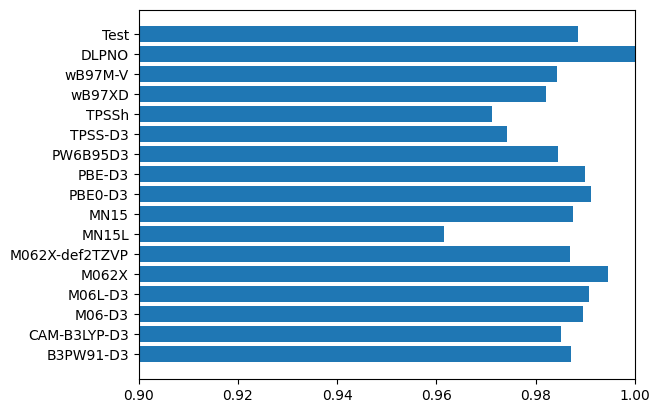

In [ ]:
all_results = pd.read_csv("E:\work\B_Cl_Nu\Benchmark_new\TS_Energies.csv")
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from matplotlib import pyplot as plt
# import numpy as np
standard_value = np.array(all_results['DLPNO'])[[0,1,2,3,4,5,6,7,9,10,13]]
scores = []
r2s = []
maes = []
maes2 = []
for key in all_column:
    easy_value = np.array(all_results[key])[[0,1,2,3,4,5,6,7,9,10,13]]
    mae = mean_absolute_error(easy_value, standard_value)
    r2 = r2_score(easy_value, standard_value)
    X = np.array(easy_value).reshape(-1, 1)
    y = np.array(standard_value).reshape(-1, 1)
    model = LinearRegression().fit(X, y)
    mae2 = mean_absolute_error(model.predict(X), y)
    score = model.score(X, y)
    scores.append(score)
    r2s.append(r2)
    maes.append(mae)
    maes2.append(mae2)
    # print(f"{key}:{model.score(X, y), model.coef_, model.intercept_}")
plt.barh(all_column, scores)
plt.xlim(0.9, 1)
plt.show()


In [41]:
# Time Cost
import re
all_times = {}
pattern = r'TOTAL RUN TIME:\s*(?P<days>\d+)\s*days\s*(?P<hours>\d+)\s*hours\s*(?P<minutes>\d+)\s*minutes\s*(?P<seconds>\d+)\s*seconds\s*(?P<msec>\d+)\s*msec'
time_to_min = lambda x: int(x[0])*24*60 + int(x[1])*60 + int(x[2]) + int(x[3])/60
for name in calc_dict.keys():
    log = Logfile(rf'E:\work\B_Cl_Nu\Benchmark_new\OPT\{name}.log')
    G_cor[name] = log.all_engs[-1]
    for method in dft_methods.keys():
        log_file = rf'E:\work\B_Cl_Nu\Benchmark_new\SPE\{method}_{name}.log'
        if "M05" in method:
            continue
        temp_log = Logfile(log_file)
        if method not in all_times.keys():
            all_times[method] = temp_log.running_time
        else:
            all_times[method] += temp_log.running_time
    for method in ['wB97M-V', "DLPNO"]:
        with open(rf'E:\work\B_Cl_Nu\Benchmark_new\{method}\{method}_{name}.out', "rt") as f:
            for line in f.readlines():
                if "TOTAL RUN TIME" in line:
                    time_line = line
                    break
        match = re.search(pattern, time_line)
        time = time_to_min(match.groups())
        if method not in all_times.keys():
            all_times[method] = time
        else:
            all_times[method] += time


FileNotFoundError: [Errno 2] No such file or directory: 'E:\\work\\B_Cl_Nu\\Benchmark_new\\DLPNO\\DLPNO_B_00401_L_00146_Cl_00443.out'

In [94]:
all_column_ = [each.replace('wB', 'ωB').replace("XD", 'X-D').replace('-def2TVVP', '/def2-TZVP') for each in all_column] 
all_column_ = [each + '/6-311+G(d,p)' for each in all_column_] 

In [106]:
all_column

['B3PW91-D3',
 'CAM-B3LYP-D3',
 'M06-D3',
 'M06L-D3',
 'M062X',
 'M062X-def2TZVP',
 'MN15L',
 'MN15',
 'PBE0-D3',
 'PBE-D3',
 'PW6B95D3',
 'TPSS-D3',
 'TPSSh',
 'wB97XD',
 'wB97M-V',
 'DLPNO',
 'Test']

In [104]:
all_column_ = ['B3PW91-D3/6-311+G(d,p)',
 'CAM-B3LYP-D3/6-311+G(d,p)',
 'M06-D3/6-311+G(d,p)',
 'M06-L-D3/6-311+G(d,p)',
 'M06-2X/6-311+G(d,p)',
 'M06-2X/def2-TZVP',
 'MN15-L/6-311+G(d,p)',
 'MN15/6-311+G(d,p)',
 'PBE0-D3/6-311+G(d,p)',
 'PBE-D3/6-311+G(d,p)',
 'PW6B95-D3/6-311+G(d,p)',
 'TPSS-D3/6-311+G(d,p)',
 'TPSSh/6-311+G(d,p)',
 'ωB97X-D/6-311+G(d,p)',
 'ωB97M-V/6-311+G(d,p)',
 'DLPNO-CCSD(T)/cc-pVTZ',
 'Test/6-311+G(d,p)']

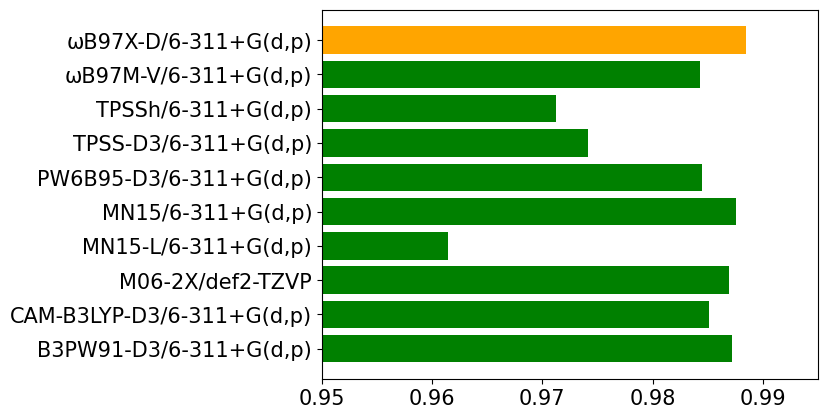

In [105]:
score_df = pd.DataFrame({"name": all_column_, "scores": scores, 'r2s': r2s, 'maes': maes, 'maes2': maes2})
target_column = 'scores'
score_df = score_df.loc[(score_df[target_column] <= score_df[target_column].iloc[-1]) ]#| (score_df['name'] == 'DLPNO')]
# score_df = score_df.loc[(score_df[target_column] >= score_df[target_column].iloc[-1]) ]#| (score_df['name'] == 'DLPNO')]
score_df = score_df.loc[score_df['name'] != 'ωB97X-D/6-311+G(d,p)']
score_df['name'].iloc[-1] = "ωB97X-D/6-311+G(d,p)"
plt.barh(score_df['name'][:-1], score_df[target_column][:-1], color='green')
plt.barh(score_df['name'][-1:], score_df[target_column][-1:], color='orange')
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.xlim(0.95, 0.995)
plt.savefig("Figure/Figure2_BenchmarkMAE.png", dpi=300, bbox_inches="tight")


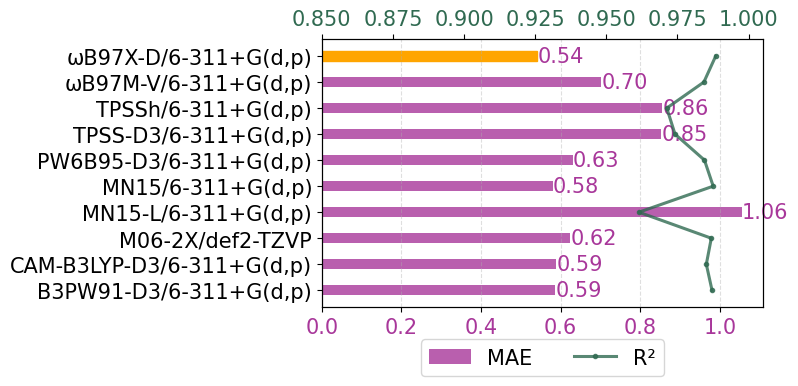

In [110]:
import pandas as pd
import matplotlib.pyplot as plt


# ----------------------- Drawing part -----------------------
fig, ax1 = plt.subplots(figsize=(8, 4))

# 1. MAE uses horizontal histogram (principal axis)
bars = ax1.barh(score_df['name'], score_df['maes2'], 
                color='#a8379a', alpha=0.8, height=0.38, label='MAE')

# Special mark the last one (if you still want to keep your logic)
bars[-1].set_color('orange')
bars[-1].set_alpha(1.0)

# ax1.set_xlabel('MAE', fontsize=14, color='darkred')
ax1.tick_params(axis='x', labelcolor='#a8379a', labelsize=15)
# ax1.set_ylabel('model/method', fontsize=14)
ax1.tick_params(axis='y', labelsize=15)
ax1.grid(axis='x', linestyle='--', alpha=0.4)

# Add numerical labels to columns (optional, but recommended)
for bar in bars:
    width = bar.get_width()
    ax1.text(width + 0.0005, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', va='center', fontsize=15, color='#a8379a')

# 2. R² uses a line chart (secondary coordinates axis)
ax2 = ax1.twiny()   # Shared y-axis but independent x-axis

ax2.plot(score_df['scores'], score_df['name'], 
         color='#306a51', marker='o', markersize=3, 
         linewidth=2.2, label='R²', alpha=0.8)

# ax2.set_xlabel('R²', fontsize=14, color='navy')
ax2.tick_params(axis='x', labelcolor='#306a51', labelsize=15)
# Optional: Set the display range of R² to make it easier to see the difference
ax2.set_xlim(0.85, 1.005)  

# # Add numerical labels to polyline points (optional)
# for i, r2 in enumerate(score_df['r2s'].to_numpy()):
#     ax2.text(r2 + 0.001, score_df['name'].to_numpy()[i], 
#              f'{r2:.4f}', va='center', fontsize=11, color='navy')

# # Legend (put it in the right place)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
           loc='upper center', bbox_to_anchor=(0.5, -0.08), 
           ncol=2, fontsize=15)

# plt.title('Model performance comparison: MAE vs R²', fontsize=15, pad=15)
plt.tight_layout()

plt.savefig("Figure/Figure2_Benchmark_MAE_R2_combined.png", 
            dpi=300, bbox_inches="tight")
plt.show()

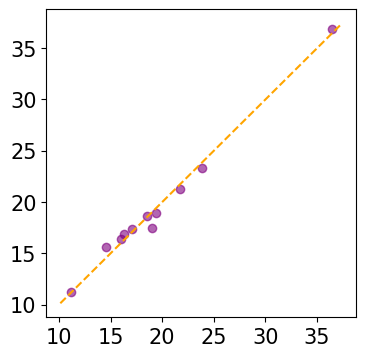

In [117]:
plt.figure(figsize=(4, 4))
model = LinearRegression()
all_results = pd.read_csv("E:\work\B_Cl_Nu\Benchmark_new\TS_Energies.csv")
all_results = all_results.iloc[[0,1,2,3,4,5,6,7,9,10,13]]
model.fit(all_results['Test'].values.reshape(-1, 1), all_results['DLPNO'].values.reshape(-1, 1))
pred = model.predict(all_results['Test'].values.reshape(-1, 1))
plt.scatter(all_results['DLPNO'], pred, color='purple', alpha=0.6)
plt.plot([min(all_results['DLPNO'])-1, max(all_results['DLPNO'])+1], [min(all_results['DLPNO'])-1, max(all_results['DLPNO'])+1], color='orange', linestyle='--')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.savefig("Figure/Figure2_Benchmark_Test_vs_DLPNO.png", dpi=300, bbox_inches="tight")

In [113]:
all_results

,Name,B3PW91-D3,CAM-B3LYP-D3,M06-D3,M06L-D3,M062X,M062X-def2TZVP,MN15L,MN15,PBE0-D3,PBE-D3,PW6B95D3,TPSS-D3,TPSSh,wB97XD,wB97M-V,DLPNO,Test
0,B_00388_L_00001_Cl_00475,14.294905,17.727110,12.844305,12.590649,18.110808,18.710688,17.257010,17.489905,15.200138,11.072964,15.164879,11.935666,16.499819,17.037896,17.951976,1.936590e+01,14.914297
1,B_00388_L_00001_Cl_00477,11.698845,15.042235,10.493207,10.361165,15.346656,16.113639,14.678031,14.869298,12.557835,8.588677,12.587503,9.426432,13.857168,14.203102,15.424421,1.704584e+01,13.046710
2,B_00388_L_00001_Cl_00490,10.822904,13.830106,9.908927,9.655441,14.400087,15.061732,13.974773,14.013672,11.750179,7.716277,11.690387,8.482413,12.812353,13.167636,14.511477,1.597402e+01,11.920285
3,B_00388_L_00001_Cl_00506,14.496260,17.396309,11.790783,11.562107,17.055431,17.515204,15.135938,15.782491,15.156803,11.660435,15.125714,12.466406,16.783345,16.883408,17.207296,1.899351e+01,13.152378
4,B_00388_L_00001_Cl_00519,6.225825,9.103277,3.809621,4.237206,9.243857,9.804056,7.642530,8.459896,6.706911,2.931303,7.233416,4.229553,8.261135,8.354546,9.719875,1.112408e+01,5.818808
5,B_00388_L_00069_Cl_00490,15.196255,18.814083,15.257137,14.934925,19.763540,21.259424,21.451151,20.869921,16.594725,12.162464,16.541155,12.125786,17.231456,18.849498,21.242671,2.175793e+01,17.621198
6,B_00388_L_00072_Cl_00490,17.566450,21.232928,19.049946,17.659230,22.250071,24.256398,21.970434,22.616624,19.221505,15.003174,17.830094,14.543193,21.261945,21.324313,23.422038,2.380854e+01,20.116370
7,B_00388_L_00072_Cl_00519,10.903536,15.330307,10.452548,9.582560,15.791076,17.270088,12.615141,14.940457,12.250504,7.913960,11.430083,7.944885,15.015581,15.054954,16.869997,1.632463e+01,12.513505
8,B_00391_L_00033_Cl_00477,16.537402,20.524020,17.088205,16.019432,20.937951,22.237494,22.003257,22.417934,17.976814,13.974131,17.861381,13.375639,19.171007,20.544442,21.556779,2.075010e+01,19.380394
9,B_00391_L_00033_Cl_00519,9.254714,13.760560,7.880053,6.557983,13.901349,15.091822,11.156142,13.341226,10.702384,6.662745,10.565154,6.387620,13.606420,13.586256,14.854389,1.458056e+01,11.033653
